# GloFAS

In [346]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [347]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from src.constants import *
from src.datasources import glofas

In [348]:
# glofas.process_reanalysis()

In [349]:
# glofas.process_reforecast_ensembles(skip_lt_groups=["lt1104-1104"])

In [350]:
glofas.process_reforecast_frac()

In [351]:
ens = glofas.load_reforecast_ensembles()
ens["leadtime"] -= 1

In [352]:
ens

,number,time,dis24,valid_time,leadtime
461100,1,2003-06-01,176.531250,2003-06-02,0
461365,2,2003-06-01,176.562500,2003-06-02,0
461630,3,2003-06-01,178.718750,2003-06-02,0
461895,4,2003-06-01,176.500000,2003-06-02,0
462160,5,2003-06-01,180.593750,2003-06-02,0
...,...,...,...,...,...
89619,6,2022-11-30,131.453125,2023-01-14,44
90014,7,2022-11-30,131.531250,2023-01-14,44
90409,8,2022-11-30,130.843750,2023-01-14,44
90804,9,2022-11-30,130.578125,2023-01-14,44


In [353]:
ens_mean = (
    ens.groupby(["time", "valid_time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
    .rename(columns={"dis24": "dis24_mean"})
)
ens_mean

,time,valid_time,leadtime,dis24_mean
0,2003-06-01,2003-06-02,0,177.359375
1,2003-06-01,2003-06-03,1,175.403122
2,2003-06-01,2003-06-04,2,173.890625
3,2003-06-01,2003-06-05,3,173.784378
4,2003-06-01,2003-06-06,4,172.512497
...,...,...,...,...
68510,2022-11-30,2023-01-10,40,142.311722
68511,2022-11-30,2023-01-11,41,139.352341
68512,2022-11-30,2023-01-12,42,136.464844
68513,2022-11-30,2023-01-13,43,133.656250


In [354]:
ref = glofas.load_reforecast_frac()
# We subtract one from the leadtime because in the
# GloFAS interface, we presume the first box corresponds to
# the smallest leadtime.
# So, the valid_time here is one day later than the actual valid time,
# which is reported in the GloFAS interface.
ref["leadtime"] -= 1

In [355]:
ref

,time,leadtime,valid_time,2yr_thresh,2yr_thresh_max,2yr_thresh_min,2yr_thresh_mean,2yr_thresh_median,5yr_thresh
0,2003-06-01,0,2003-06-02,0.0,0.0,0.0,0.0,0.0,0.0
1,2003-06-01,1,2003-06-03,0.0,0.0,0.0,0.0,0.0,0.0
2,2003-06-01,2,2003-06-04,0.0,0.0,0.0,0.0,0.0,0.0
3,2003-06-01,3,2003-06-05,0.0,0.0,0.0,0.0,0.0,0.0
4,2003-06-01,4,2003-06-06,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
68510,2022-11-30,40,2023-01-10,0.0,0.0,0.0,0.0,0.0,0.0
68511,2022-11-30,41,2023-01-11,0.0,0.0,0.0,0.0,0.0,0.0
68512,2022-11-30,42,2023-01-12,0.0,0.0,0.0,0.0,0.0,0.0
68513,2022-11-30,43,2023-01-13,0.0,0.0,0.0,0.0,0.0,0.0


In [356]:
ref.groupby("leadtime").size()

leadtime
0     1479
1     1479
2     1479
3     1479
4     1479
5     1502
6     1502
7     1502
8     1502
9     1502
10    1516
11    1516
12    1516
13    1516
14    1516
15    1516
16    1516
17    1516
18    1516
19    1516
20    1516
21    1516
22    1516
23    1516
24    1516
25    1535
26    1535
27    1535
28    1535
29    1535
30    1535
31    1535
32    1535
33    1535
34    1535
35    1550
36    1550
37    1550
38    1550
39    1550
40    1554
41    1554
42    1554
43    1554
44    1554
dtype: int64

In [357]:
n_years = 20

In [358]:
max_complete_lt = 44
ref = ref[ref["leadtime"] <= max_complete_lt]

In [359]:
rea = glofas.load_reanalysis()

In [360]:
rp_a = 4
rp_a_eff = (n_years - 1) / ((n_years + 1) / rp_a - 1)

rea = glofas.load_reanalysis()
rea = rea[rea["time"].dt.year.isin(ref["time"].dt.year.unique())]
rea_peaks = rea.loc[rea.groupby(rea["time"].dt.year)["dis24"].idxmax()]
q_rp_a = rea_peaks["dis24"].quantile(1 - 1 / rp_a_eff)
rea_peaks["trigger"] = rea_peaks["dis24"] >= q_rp_a
rea_peaks["year"] = rea_peaks["time"].dt.year
rea_peaks["cerf"] = rea_peaks["year"].isin(CERF_YEARS)
rea_peaks["rank"] = rea_peaks["dis24"].rank(ascending=False)
rea_peaks["rp"] = len(rea_peaks) / rea_peaks["rank"]
rea_peaks.sort_values("rank", ascending=False)

,time,dis24,trigger,year,cerf,rank,rp
6827,2021-09-10,1138.0391,False,2021,False,20.0,1.000000
2444,2009-09-10,1495.7578,False,2009,False,19.0,1.052632
5388,2017-10-02,1701.5703,False,2017,False,18.0,1.111111
2098,2008-09-29,1808.2734,False,2008,False,17.0,1.176471
4636,2015-09-11,1913.9453,False,2015,False,16.0,1.250000
4278,2014-09-18,2316.0469,False,2014,False,15.0,1.333333
626,2004-09-18,2338.4140,False,2004,False,14.0,1.428571
3914,2013-09-19,2339.5469,False,2013,False,13.0,1.538462
3190,2011-09-26,2377.5781,False,2011,False,12.0,1.666667
5022,2016-10-01,2464.1484,False,2016,False,11.0,1.818182


<Axes: xlabel='year'>

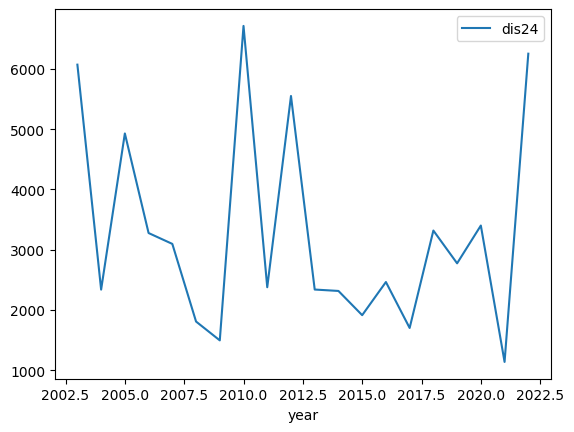

In [361]:
rea_peaks.plot(x="year", y="dis24")

## Readiness

In [416]:
n_years = 20
rp_ceiling = 3.5
rp_effective = (n_years - 1) / ((n_years + 1) / rp_ceiling - 1)
print(rp_ceiling)
print(rp_effective)

3.5
3.8


In [417]:
21 / 6

3.5

In [418]:
rp_f = rp_effective
lt_min = 0
thresh_yr = 2
maxmin = "_mean"

val_col = f"{thresh_yr}yr_thresh{maxmin}"

dfs = []
dfs_threshs = []
dfs_first_trigger = []
dfs_last_trigger = []

for lt in ref["leadtime"].unique():
    if lt < lt_min or lt >= 30:
        continue

    dff = ref[(ref["leadtime"] <= lt) & (ref["leadtime"] >= lt_min)]
    df_in = dff.loc[dff.groupby(dff["time"].dt.year)[val_col].idxmax()]
    df_in["lt_max"] = lt
    thresh = df_in[val_col].quantile(1 - 1 / rp_f) - 0.00001
    df_in["trigger"] = df_in[val_col] >= thresh
    # print(lt, thresh)
    df_first_trigger = dff.loc[
        dff[dff[val_col] >= thresh]
        .groupby(dff["time"].dt.year)["time"]
        .idxmin()
    ]
    df_last_trigger = dff.loc[
        dff[dff[val_col] >= thresh]
        .groupby(dff["time"].dt.year)["time"]
        .idxmax()
    ]
    df_first_trigger["lt_max"] = lt
    df_last_trigger["lt_max"] = lt
    dfs_threshs.append({"lt_max": lt, "thresh": thresh})
    dfs.append(df_in)
    dfs_first_trigger.append(df_first_trigger)
    dfs_last_trigger.append(df_last_trigger)

ref_threshs = pd.DataFrame(dfs_threshs)
ref_peaks = pd.concat(dfs, ignore_index=True)
ref_peaks["year"] = ref_peaks["time"].dt.year
ref_first_triggers = pd.concat(dfs_first_trigger, ignore_index=True)
ref_last_triggers = pd.concat(dfs_last_trigger, ignore_index=True)

compare = rea_peaks.merge(ref_peaks, on="year", suffixes=["_a", "_f"])
for indicator in ["cerf", "trigger_a"]:
    compare[f"TP_{indicator}"] = compare[indicator] & compare["trigger_f"]
    compare[f"FP_{indicator}"] = ~compare[indicator] & compare["trigger_f"]
    compare[f"TN_{indicator}"] = ~compare[indicator] & ~compare["trigger_f"]
    compare[f"FN_{indicator}"] = compare[indicator] & ~compare["trigger_f"]

compare = compare.sort_values(["year", "lt_max"])

dicts = []
for lt, group in compare.groupby("lt_max"):
    TPR = group["TP_trigger_a"].sum() / group["trigger_a"].sum()
    PPV = group["TP_trigger_a"].sum() / group["trigger_f"].sum()
    TPR_C = group["TP_cerf"].sum() / group["cerf"].sum()
    PPV_C = group["TP_cerf"].sum() / group["trigger_f"].sum()
    dicts.append(
        {"TPR": TPR, "PPV": PPV, "TPR_C": TPR_C, "PPV_C": PPV_C, "lt_max": lt}
    )

metrics = pd.DataFrame(dicts)
display(metrics.merge(ref_threshs))

,TPR,PPV,TPR_C,PPV_C,lt_max,thresh
0,1.0,0.250000,1.0,0.100000,0,-0.00001
1,1.0,0.250000,1.0,0.100000,1,-0.00001
2,1.0,0.250000,1.0,0.100000,2,-0.00001
3,1.0,0.250000,1.0,0.100000,3,-0.00001
4,1.0,0.250000,1.0,0.100000,4,-0.00001
5,1.0,0.250000,1.0,0.100000,5,-0.00001
6,1.0,0.250000,1.0,0.100000,6,-0.00001
7,1.0,0.833333,1.0,0.333333,7,0.09999
8,1.0,0.833333,1.0,0.333333,8,0.39999
9,1.0,0.833333,1.0,0.333333,9,0.39999


Text(0.5, 1.0, "Fleuve Chari à N'Djamena\nPics annuels GloFAS (2003-2022)")

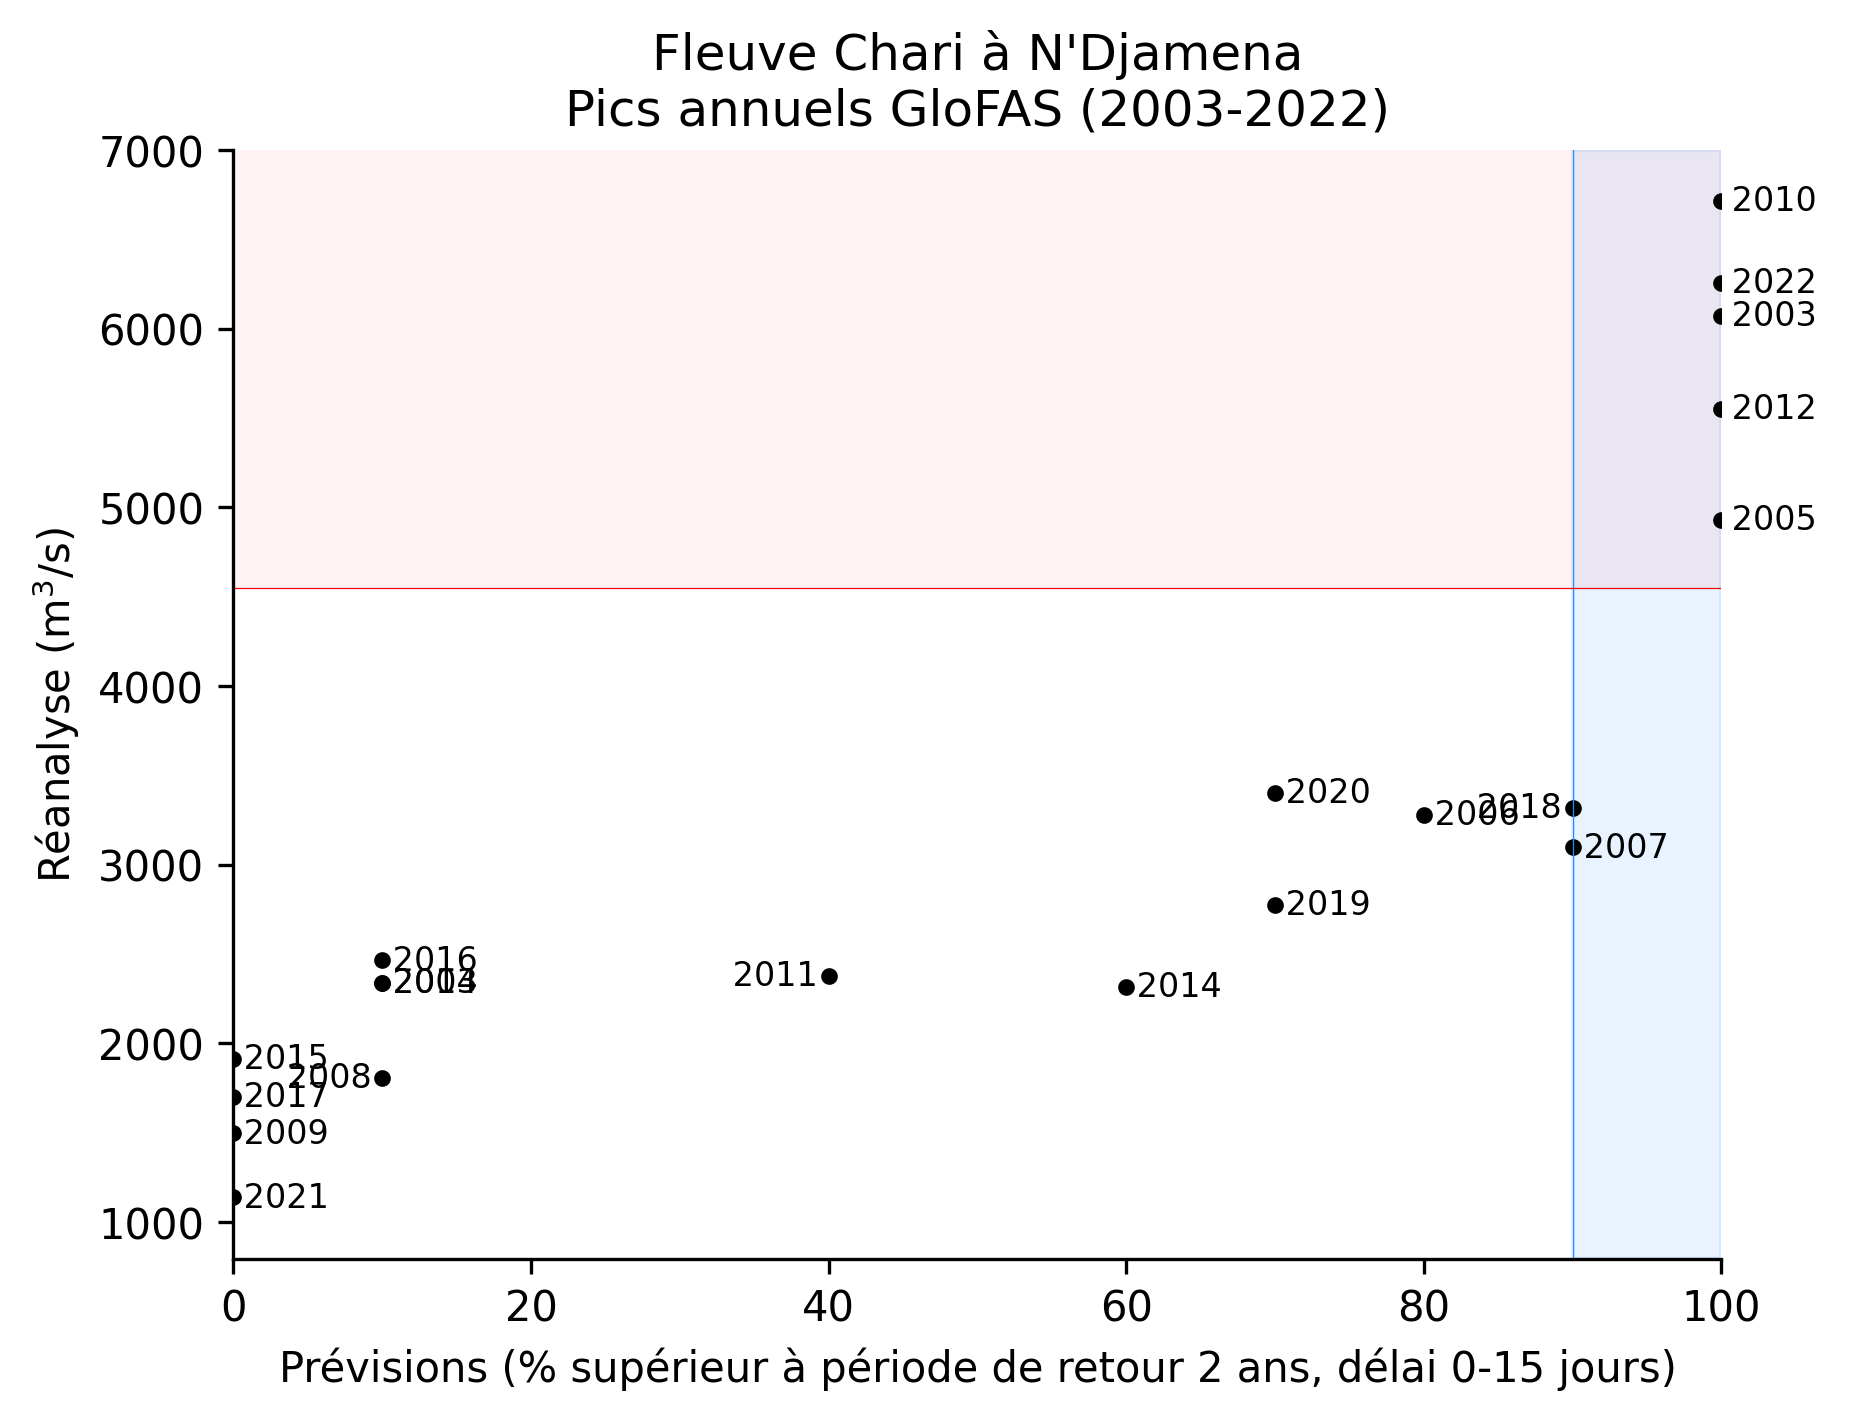

In [419]:
max_lt = 15

# 3yr
rp_a_3 = rea_peaks["dis24"].quantile(1 - 1 / rp_a_eff)
rp_a_target = rea_peaks["dis24"].quantile(1 - 1 / rp_a_eff)

rp_f = ref_threshs.set_index("lt_max").loc[max_lt, "thresh"] * 100
compare_lt = compare[compare["lt_max"] == max_lt].copy()
compare_lt["percent"] = compare_lt[val_col] * 100
fig, ax = plt.subplots(dpi=300)
compare_lt.plot(
    y="dis24",
    x="percent",
    ax=ax,
    marker=".",
    color="k",
    linestyle="",
    legend=False,
)

ax.axvline(x=rp_f, color="dodgerblue", linestyle="-", linewidth=0.3)
ax.axvspan(
    rp_f,
    100,
    ymin=0,
    ymax=1,
    color="dodgerblue",
    alpha=0.1,
)

ax.axhline(y=rp_a_target, color="red", linestyle="-", linewidth=0.3)
ax.axhspan(
    rp_a_target,
    8000,
    color="red",
    alpha=0.05,
    linestyle="None",
)

for year, row in compare_lt.set_index("year").iterrows():
    flip_years = [2018, 2011, 2008]
    ha = "right" if year in flip_years else "left"
    ax.annotate(
        f" {year} ",
        (row["percent"], row["dis24"]),
        color="k",
        fontsize=8,
        va="center",
        ha=ha,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Réanalyse (m$^3$/s)")
ax.set_xlabel(
    f"Prévisions (% supérieur à période de retour "
    f"{thresh_yr} ans, délai {lt_min}-{max_lt} jours)"
)
ax.set_ylim(top=7000)
ax.set_xlim(right=100, left=0)
ax.set_title("Fleuve Chari à N'Djamena\nPics annuels GloFAS (2003-2022)")

In [420]:
ref_first_triggers[ref_first_triggers["lt_max"] == max_lt]

,time,leadtime,valid_time,2yr_thresh,2yr_thresh_max,2yr_thresh_min,2yr_thresh_mean,2yr_thresh_median,5yr_thresh,lt_max
188,2003-08-17,14,2003-09-01,0.9,0.9,0.9,0.9,0.9,0.1,15
189,2005-08-21,12,2005-09-03,1.0,0.9,1.0,1.0,1.0,0.0,15
190,2007-09-04,15,2007-09-20,0.9,0.8,0.9,0.9,0.9,0.3,15
191,2010-08-22,14,2010-09-06,1.0,0.8,1.0,0.9,0.9,0.1,15
192,2012-08-15,13,2012-08-29,0.9,0.9,0.9,0.9,0.9,0.2,15
193,2018-08-28,14,2018-09-12,0.9,0.7,0.9,0.9,0.9,0.1,15
194,2022-09-04,11,2022-09-16,0.9,0.6,1.0,0.9,0.9,0.0,15


In [421]:
ref_last_triggers[ref_last_triggers["lt_max"] == max_lt]

,time,leadtime,valid_time,2yr_thresh,2yr_thresh_max,2yr_thresh_min,2yr_thresh_mean,2yr_thresh_median,5yr_thresh,lt_max
188,2003-10-05,0,2003-10-06,1.0,1.0,1.0,1.0,1.0,0.0,15
189,2005-10-09,0,2005-10-10,1.0,0.0,1.0,1.0,1.0,0.0,15
190,2007-09-04,15,2007-09-20,0.9,0.8,0.9,0.9,0.9,0.3,15
191,2010-10-05,0,2010-10-06,1.0,1.0,1.0,1.0,1.0,0.0,15
192,2012-09-28,0,2012-09-29,1.0,1.0,1.0,1.0,1.0,0.0,15
193,2018-08-31,13,2018-09-14,0.9,0.8,0.9,0.9,0.9,0.0,15
194,2022-10-05,0,2022-10-06,1.0,1.0,1.0,1.0,1.0,0.0,15


In [327]:
ref[ref["time"] == "2010-08-28"].merge(ens_mean).sort_values(
    ["5yr_thresh", "dis24_mean"], ascending=False
)

,time,leadtime,valid_time,2yr_thresh,2yr_thresh_max,2yr_thresh_min,2yr_thresh_mean,2yr_thresh_median,5yr_thresh,dis24_mean
39,2010-08-28,39,2010-10-07,1.0,1.0,1.0,1.0,1.0,0.9,7981.021973
40,2010-08-28,40,2010-10-08,1.0,1.0,1.0,1.0,1.0,0.9,7974.766602
41,2010-08-28,41,2010-10-09,1.0,1.0,1.0,1.0,1.0,0.9,7957.385742
38,2010-08-28,38,2010-10-06,1.0,1.0,1.0,1.0,1.0,0.9,7954.734375
42,2010-08-28,42,2010-10-10,1.0,1.0,1.0,1.0,1.0,0.9,7943.887695
43,2010-08-28,43,2010-10-11,1.0,1.0,1.0,1.0,1.0,0.9,7912.208008
37,2010-08-28,37,2010-10-05,1.0,1.0,1.0,1.0,1.0,0.9,7897.591309
44,2010-08-28,44,2010-10-12,1.0,1.0,1.0,1.0,1.0,0.9,7854.635254
36,2010-08-28,36,2010-10-04,1.0,1.0,1.0,1.0,1.0,0.9,7838.536621
23,2010-08-28,23,2010-09-21,1.0,1.0,1.0,1.0,1.0,0.9,7816.601562


## Action

In [422]:
n_years = 20
rp_ceiling = 4
rp_effective = (n_years - 1) / ((n_years + 1) / rp_ceiling - 1)
print(rp_ceiling)
print(rp_effective)

4
4.470588235294118


In [423]:
rp_f = rp_effective
lt_min = 0
thresh_yr = 2
maxmin = ""

val_col = f"{thresh_yr}yr_thresh{maxmin}"

dfs = []
dfs_threshs = []
dfs_first_trigger = []
dfs_last_trigger = []

for lt in ref["leadtime"].unique():
    if lt < lt_min or lt >= 30:
        continue

    dff = ref[(ref["leadtime"] <= lt) & (ref["leadtime"] >= lt_min)]
    df_in = dff.loc[dff.groupby(dff["time"].dt.year)[val_col].idxmax()]
    df_in["lt_max"] = lt
    thresh = df_in[val_col].quantile(1 - 1 / rp_f)
    df_in["trigger"] = df_in[val_col] >= thresh
    # print(lt, thresh)
    df_first_trigger = dff.loc[
        dff[dff[val_col] >= thresh]
        .groupby(dff["time"].dt.year)["time"]
        .idxmin()
    ]
    df_last_trigger = dff.loc[
        dff[dff[val_col] >= thresh]
        .groupby(dff["time"].dt.year)["time"]
        .idxmax()
    ]
    df_first_trigger["lt_max"] = lt
    df_last_trigger["lt_max"] = lt
    dfs_threshs.append({"lt_max": lt, "thresh": thresh})
    dfs.append(df_in)
    dfs_first_trigger.append(df_first_trigger)
    dfs_last_trigger.append(df_last_trigger)

ref_threshs = pd.DataFrame(dfs_threshs)
ref_peaks = pd.concat(dfs, ignore_index=True)
ref_peaks["year"] = ref_peaks["time"].dt.year
ref_first_triggers = pd.concat(dfs_first_trigger, ignore_index=True)
ref_last_triggers = pd.concat(dfs_last_trigger, ignore_index=True)

compare = rea_peaks.merge(ref_peaks, on="year", suffixes=["_a", "_f"])
for indicator in ["cerf", "trigger_a"]:
    compare[f"TP_{indicator}"] = compare[indicator] & compare["trigger_f"]
    compare[f"FP_{indicator}"] = ~compare[indicator] & compare["trigger_f"]
    compare[f"TN_{indicator}"] = ~compare[indicator] & ~compare["trigger_f"]
    compare[f"FN_{indicator}"] = compare[indicator] & ~compare["trigger_f"]

compare = compare.sort_values(["year", "lt_max"])

dicts = []
for lt, group in compare.groupby("lt_max"):
    TPR = group["TP_trigger_a"].sum() / group["trigger_a"].sum()
    PPV = group["TP_trigger_a"].sum() / group["trigger_f"].sum()
    TPR_C = group["TP_cerf"].sum() / group["cerf"].sum()
    PPV_C = group["TP_cerf"].sum() / group["trigger_f"].sum()
    dicts.append(
        {"TPR": TPR, "PPV": PPV, "TPR_C": TPR_C, "PPV_C": PPV_C, "lt_max": lt}
    )

metrics = pd.DataFrame(dicts)
display(metrics.merge(ref_threshs))

,TPR,PPV,TPR_C,PPV_C,lt_max,thresh
0,1.0,1.000000,1.0,0.400000,0,0.750
1,1.0,1.000000,1.0,0.400000,1,0.750
2,1.0,1.000000,1.0,0.400000,2,0.750
3,1.0,1.000000,1.0,0.400000,3,0.750
4,1.0,1.000000,1.0,0.400000,4,0.750
5,1.0,1.000000,1.0,0.400000,5,0.750
6,1.0,1.000000,1.0,0.400000,6,0.750
7,1.0,1.000000,1.0,0.400000,7,0.800
8,1.0,1.000000,1.0,0.400000,8,0.850
9,1.0,1.000000,1.0,0.400000,9,0.850


Text(0.5, 1.0, "Fleuve Chari à N'Djamena\nPics annuels GloFAS (2003-2022)")

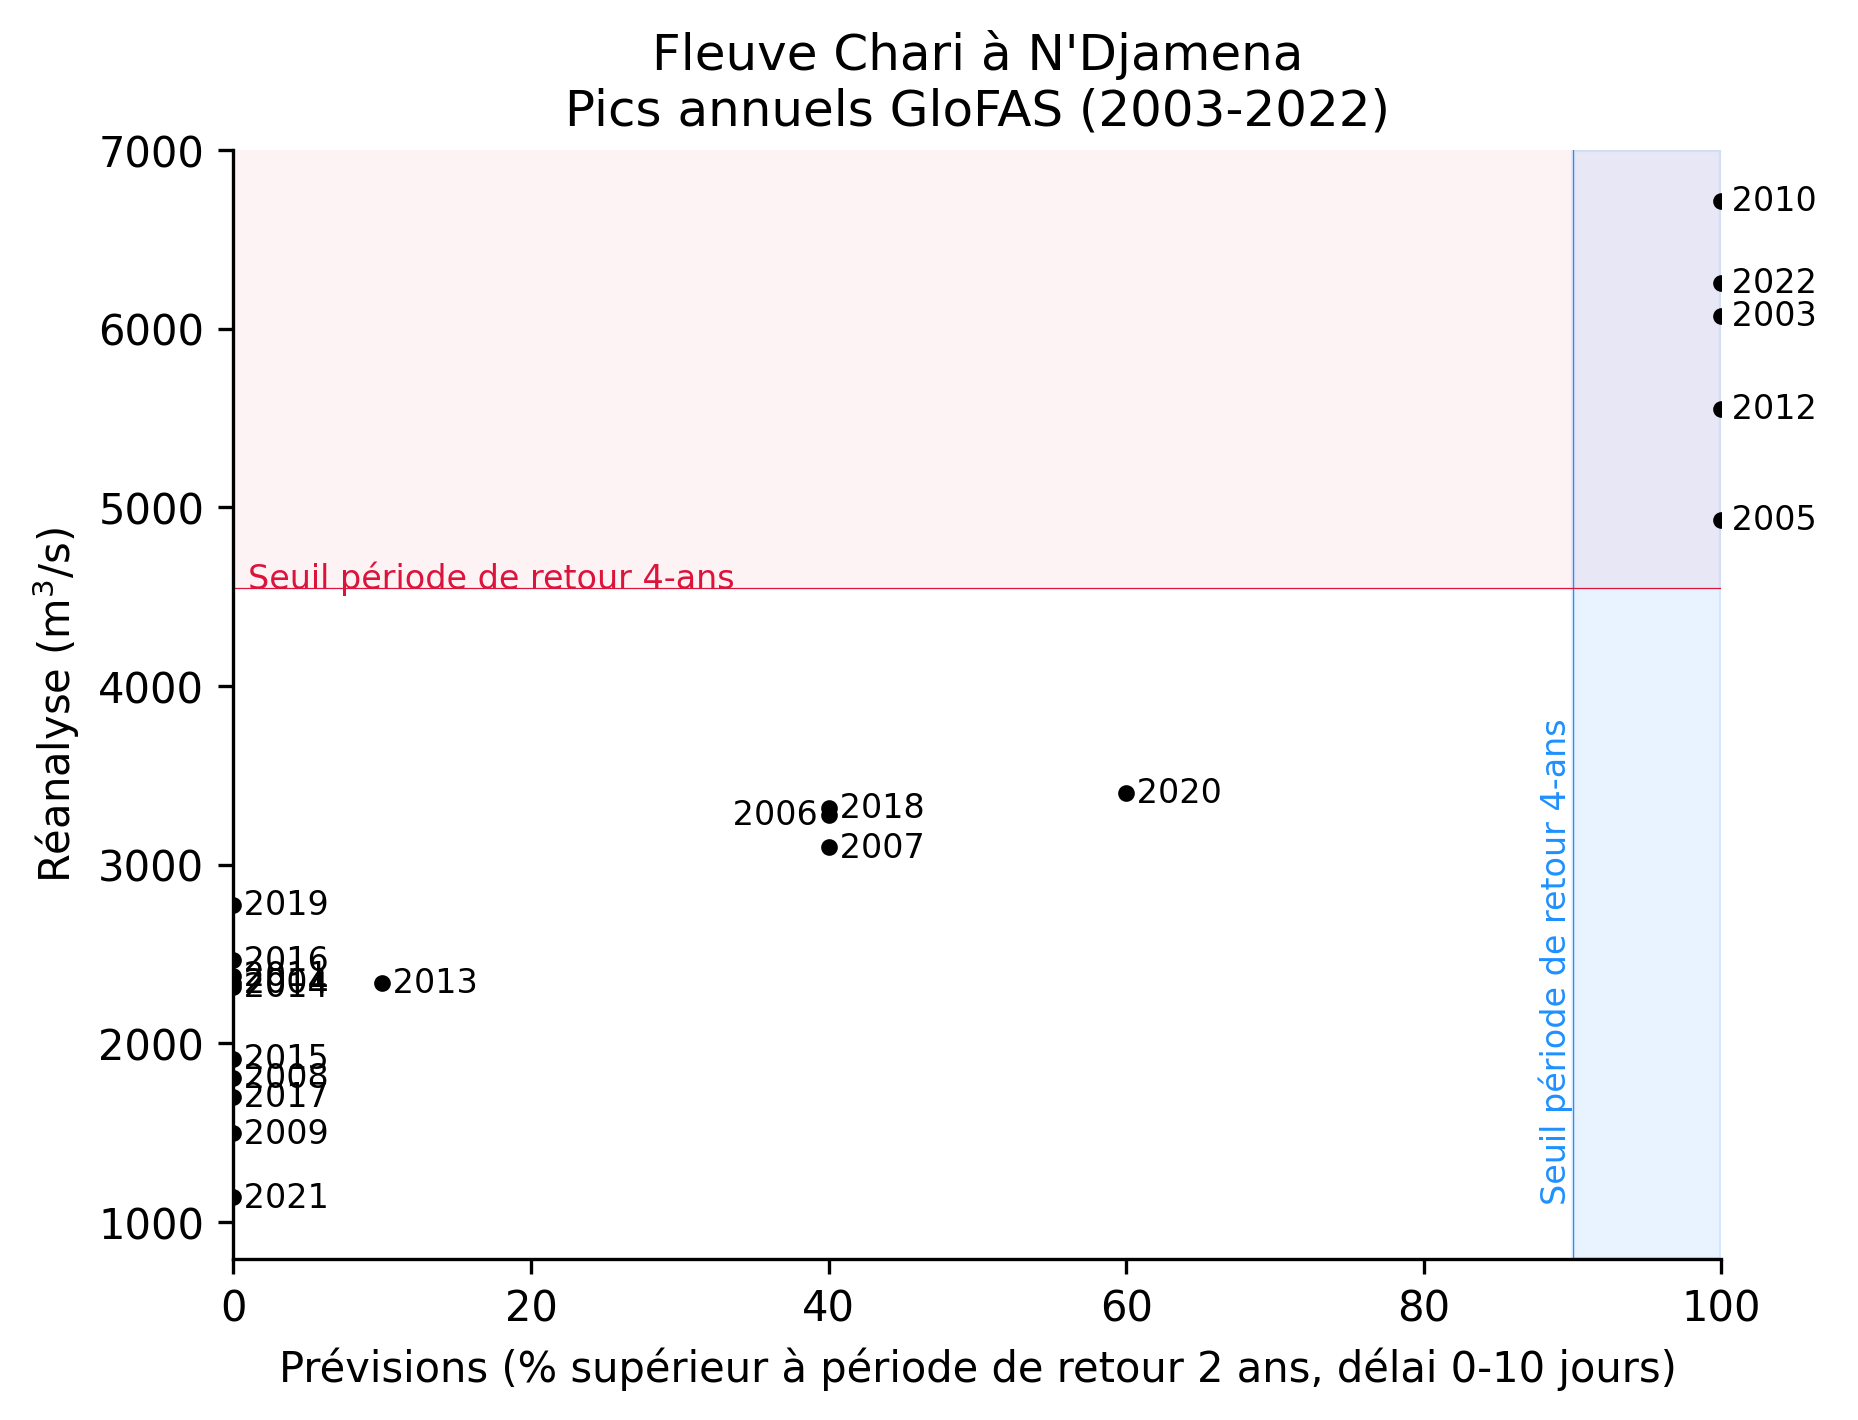

In [424]:
max_lt = 10

# 3yr
rp_a_target = rea_peaks["dis24"].quantile(1 - 1 / rp_a_eff)

rp_f = ref_threshs.set_index("lt_max").loc[max_lt, "thresh"] * 100
compare_lt = compare[compare["lt_max"] == max_lt].copy()
compare_lt["percent"] = compare_lt[val_col] * 100
fig, ax = plt.subplots(dpi=300)
compare_lt.plot(
    y="dis24",
    x="percent",
    ax=ax,
    marker=".",
    color="k",
    linestyle="",
    legend=False,
)

ax.axvline(x=rp_f, color="dodgerblue", linestyle="-", linewidth=0.3)
ax.axvspan(
    rp_f,
    100,
    ymin=0,
    ymax=1,
    color="dodgerblue",
    alpha=0.1,
)
ax.annotate(
    f"Seuil période de retour {rp_a}-ans",
    (1, rp_a_target),
    fontsize=8,
    color="crimson",
)
ax.annotate(
    f"Seuil période de retour {rp_ceiling}-ans",
    (rp_f, compare_lt["dis24"].min()),
    fontsize=8,
    color="dodgerblue",
    rotation=90,
    ha="right",
)

ax.axhline(y=rp_a_target, color="crimson", linestyle="-", linewidth=0.3)
ax.axhspan(
    rp_a_target,
    8000,
    color="crimson",
    alpha=0.05,
    linestyle="None",
)

for year, row in compare_lt.set_index("year").iterrows():
    flip_years = [2006]
    ha = "right" if year in flip_years else "left"
    ax.annotate(
        f" {year} ",
        (row["percent"], row["dis24"]),
        color="k",
        fontsize=8,
        va="center",
        ha=ha,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Réanalyse (m$^3$/s)")
ax.set_xlabel(
    f"Prévisions (% supérieur à période de retour "
    f"{thresh_yr} ans, délai {lt_min}-{max_lt} jours)"
)
ax.set_ylim(top=7000)
ax.set_xlim(right=100, left=0)
ax.set_title("Fleuve Chari à N'Djamena\nPics annuels GloFAS (2003-2022)")

In [425]:
ref_first_triggers[ref_first_triggers["lt_max"] == max_lt]

,time,leadtime,valid_time,2yr_thresh,2yr_thresh_max,2yr_thresh_min,2yr_thresh_mean,2yr_thresh_median,5yr_thresh,lt_max
50,2003-08-24,7,2003-09-01,1.0,0.9,1.0,1.0,1.0,0.0,10
51,2005-08-28,10,2005-09-08,1.0,0.9,1.0,0.9,0.9,0.0,10
52,2010-08-28,8,2010-09-06,1.0,1.0,1.0,1.0,1.0,0.0,10
53,2012-08-19,9,2012-08-29,1.0,1.0,1.0,1.0,1.0,0.1,10
54,2022-09-11,2,2022-09-14,1.0,1.0,1.0,1.0,1.0,0.0,10


In [426]:
ref_last_triggers[ref_last_triggers["lt_max"] == max_lt]

,time,leadtime,valid_time,2yr_thresh,2yr_thresh_max,2yr_thresh_min,2yr_thresh_mean,2yr_thresh_median,5yr_thresh,lt_max
50,2003-10-05,0,2003-10-06,1.0,1.0,1.0,1.0,1.0,0.0,10
51,2005-10-09,0,2005-10-10,1.0,0.0,1.0,1.0,1.0,0.0,10
52,2010-10-05,0,2010-10-06,1.0,1.0,1.0,1.0,1.0,0.0,10
53,2012-09-28,0,2012-09-29,1.0,1.0,1.0,1.0,1.0,0.0,10
54,2022-10-05,0,2022-10-06,1.0,1.0,1.0,1.0,1.0,0.0,10


In [300]:
ref[ref["time"] == "2010-09-04"].merge(ens_mean).sort_values(
    ["5yr_thresh", "dis24_mean"], ascending=False
)

,time,leadtime,valid_time,2yr_thresh,2yr_thresh_max,2yr_thresh_min,2yr_thresh_mean,2yr_thresh_median,5yr_thresh,dis24_mean
14,2010-09-04,14,2010-09-19,1.0,1.0,1.0,1.0,1.0,1.0,7695.441406
15,2010-09-04,15,2010-09-20,1.0,1.0,1.0,1.0,1.0,1.0,7688.137695
13,2010-09-04,13,2010-09-18,1.0,1.0,1.0,1.0,1.0,1.0,7678.823242
16,2010-09-04,16,2010-09-21,1.0,1.0,1.0,1.0,1.0,1.0,7666.238281
12,2010-09-04,12,2010-09-17,1.0,1.0,1.0,1.0,1.0,1.0,7609.389160
11,2010-09-04,11,2010-09-16,1.0,1.0,1.0,1.0,1.0,1.0,7466.038086
5,2010-09-04,5,2010-09-10,1.0,1.0,1.0,1.0,1.0,1.0,6476.642090
4,2010-09-04,4,2010-09-09,1.0,1.0,1.0,1.0,1.0,1.0,6406.962402
17,2010-09-04,17,2010-09-22,1.0,1.0,1.0,1.0,1.0,0.9,7640.154785
18,2010-09-04,18,2010-09-23,1.0,1.0,1.0,1.0,1.0,0.9,7614.482910


In [31]:
cols = [x for x in compare.columns if compare[x].dtype != bool]
compare[compare["lt_max"] == max_lt][cols]

,time_a,dis24,year,rank,rp,time_f,leadtime,valid_time,2yr_thresh,5yr_thresh,lt_max
10,2003-09-15,6072.0000,2003,3.0,6.666667,2003-08-24,7,2003-09-01,1.0,0.0,10
40,2004-09-18,2338.4140,2004,14.0,1.428571,2004-06-01,0,2004-06-02,0.0,0.0,10
70,2005-09-30,4930.1953,2005,5.0,4.000000,2005-08-28,10,2005-09-08,1.0,0.0,10
100,2006-09-19,3277.3750,2006,8.0,2.500000,2006-09-07,10,2006-09-18,0.4,0.0,10
130,2007-09-15,3096.8672,2007,9.0,2.222222,2007-09-04,10,2007-09-15,0.4,0.0,10
160,2008-09-29,1808.2734,2008,17.0,1.176471,2008-06-01,0,2008-06-02,0.0,0.0,10
190,2009-09-10,1495.7578,2009,19.0,1.052632,2009-06-01,0,2009-06-02,0.0,0.0,10
220,2010-09-20,6714.9453,2010,1.0,20.000000,2010-08-28,8,2010-09-06,1.0,0.0,10
250,2011-09-26,2377.5781,2011,12.0,1.666667,2011-06-01,0,2011-06-02,0.0,0.0,10
280,2012-09-17,5551.9844,2012,4.0,5.000000,2012-08-19,9,2012-08-29,1.0,0.1,10


In [32]:
ref

,time,leadtime,valid_time,2yr_thresh,5yr_thresh
0,2003-06-01,0,2003-06-02,0.0,0.0
1,2003-06-01,1,2003-06-03,0.0,0.0
2,2003-06-01,2,2003-06-04,0.0,0.0
3,2003-06-01,3,2003-06-05,0.0,0.0
4,2003-06-01,4,2003-06-06,0.0,0.0
...,...,...,...,...,...
68510,2022-11-30,40,2023-01-10,0.0,0.0
68511,2022-11-30,41,2023-01-11,0.0,0.0
68512,2022-11-30,42,2023-01-12,0.0,0.0
68513,2022-11-30,43,2023-01-13,0.0,0.0


In [33]:
dicts = []
for lt_max, group in compare.groupby("lt_max"):
    corr_in = group.corr()
    dicts.append(
        {
            "lt_max": lt_max,
            "2yr_thresh": corr_in.loc["dis24", "2yr_thresh"],
            "5yr_thresh": corr_in.loc["dis24", "5yr_thresh"],
        }
    )

df_corr = pd.DataFrame(dicts)
df_corr

,lt_max,2yr_thresh,5yr_thresh
0,0,0.918418,NaN
1,1,0.918418,NaN
2,2,0.918418,NaN
3,3,0.918418,NaN
4,4,0.918418,NaN
5,5,0.918418,NaN
6,6,0.918418,NaN
7,7,0.928035,NaN
8,8,0.949146,NaN
9,9,0.953087,0.316199


<Axes: xlabel='lt_max'>

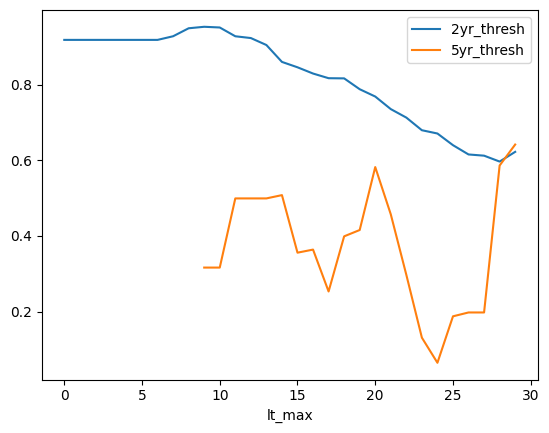

In [34]:
df_corr.set_index("lt_max").plot()

In [35]:
rea

,time,dis24
0,2003-01-01,351.32812
1,2003-01-02,347.54688
2,2003-01-03,343.89062
3,2003-01-04,340.43750
4,2003-01-05,337.18750
...,...,...
7300,2022-12-27,191.53906
7301,2022-12-28,187.07812
7302,2022-12-29,182.73438
7303,2022-12-30,178.53125
